# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv(r'C:\Users\Deepak\Data Visuvilazition\data-viz-class-material\data\co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


In [3]:
# Task 1 — Multi-series line with highlight
asia = df[df['Region'] == 'Asia'].copy()
highlight_country = 'China'

fig = go.Figure()

for country in asia['Country'].unique():
    country_data = asia[asia['Country'] == country]
    is_highlight = country == highlight_country
    
    fig.add_trace(
        go.Scatter(
            x=country_data['Year'],
            y=country_data['CO2_Mt'],
            mode='lines',
            line=dict(
                color='#D62728' if is_highlight else '#DDDDDD',
                width=3.5 if is_highlight else 1.4
            ),
            hovertemplate=f'{country}<br>%{{x}}: %{{y:,.0f}} Mt<extra></extra>',
            showlegend=False
        )
    )

highlight_end = asia[(asia['Country'] == highlight_country) & (asia['Year'] == asia['Year'].max())].iloc[0]

fig.add_annotation(
    x=highlight_end['Year'],
    y=highlight_end['CO2_Mt'],
    text=highlight_country,
    showarrow=False,
    xanchor='left',
    xshift=8,
    font=dict(color='#D62728', size=13, family='Arial')
)

fig.update_layout(
    title=dict(
        text='China dominates Asian CO2 emissions, rising far above its regional peers',
        x=0,
        font=dict(size=18, family='Arial', color='#222222')
    ),
    font=dict(family='Arial', color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=900,
    height=520,
    margin=dict(l=70, r=115, t=80, b=60),
    xaxis=dict(
        title='Year',
        showline=True,
        linecolor='#CCCCCC',
        showgrid=False,
        ticks='outside'
    ),
    yaxis=dict(
        title='CO2 emissions (million tonnes)',
        showline=True,
        linecolor='#CCCCCC',
        gridcolor='#EEEEEE',
        zeroline=False,
        ticks='outside'
    )
)

fig.show()


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


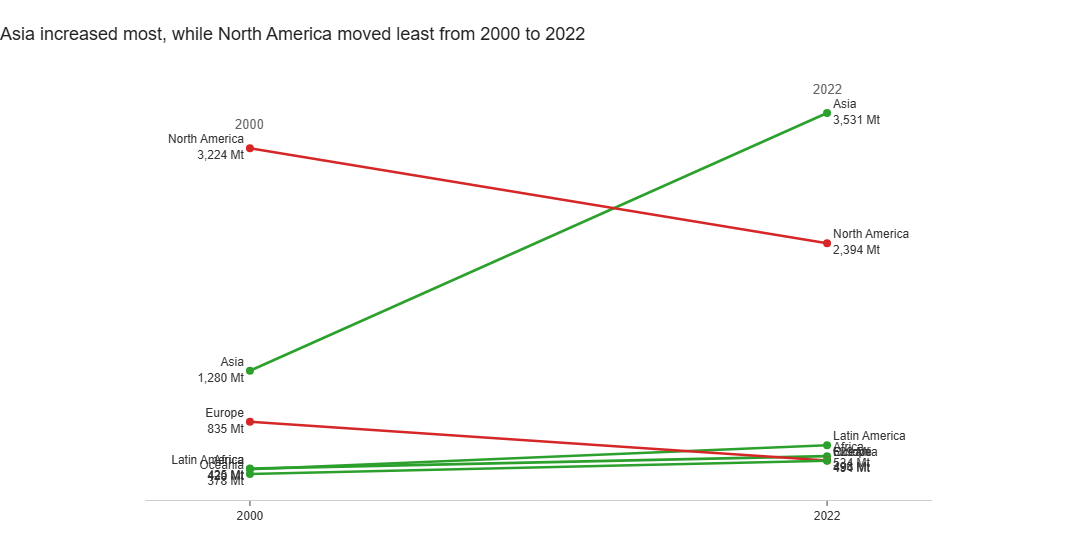

In [4]:
# Task 2 — Slopegraph: regional averages
regional_avg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
slope = regional_avg[regional_avg['Year'].isin([2000, 2022])]
slope = slope.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()
slope['Change'] = slope[2022] - slope[2000]

largest_increase = slope.loc[slope['Change'].idxmax()]
largest_decrease = slope.loc[slope['Change'].idxmin()]

increase_color = '#2CA02C'
decrease_color = '#D62728'

fig = go.Figure()

for _, row in slope.sort_values(2022, ascending=False).iterrows():
    color = increase_color if row['Change'] >= 0 else decrease_color
    fig.add_trace(
        go.Scatter(
            x=[2000, 2022],
            y=[row[2000], row[2022]],
            mode='lines+markers+text',
            line=dict(color=color, width=2.6),
            marker=dict(color=color, size=8),
            text=[f"{row['Region']}<br>{row[2000]:,.0f} Mt", f"{row['Region']}<br>{row[2022]:,.0f} Mt"],
            textposition=['middle left', 'middle right'],
            textfont=dict(color='#333333', size=12, family='Arial'),
            hovertemplate=f"{row['Region']}<br>%{{x}}: %{{y:,.0f}} Mt<extra></extra>",
            showlegend=False
        )
    )

fig.update_layout(
    title=dict(
        text=f"{largest_increase['Region']} increased most, while {largest_decrease['Region']} moved least from 2000 to 2022",
        x=0,
        font=dict(size=18, family='Arial', color='#222222')
    ),
    font=dict(family='Arial', color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=900,
    height=560,
    margin=dict(l=145, r=145, t=80, b=60),
    xaxis=dict(
        title='',
        tickmode='array',
        tickvals=[2000, 2022],
        range=[1996, 2026],
        showgrid=False,
        showline=True,
        linecolor='#CCCCCC',
        ticks='outside'
    ),
    yaxis=dict(
        title='',
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        showline=False
    )
)

fig.add_annotation(
    x=2000,
    y=slope[2000].max(),
    text='2000',
    showarrow=False,
    yshift=24,
    font=dict(size=13, color='#666666', family='Arial')
)
fig.add_annotation(
    x=2022,
    y=slope[2022].max(),
    text='2022',
    showarrow=False,
    yshift=24,
    font=dict(size=13, color='#666666', family='Arial')
)

fig.show()
